In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

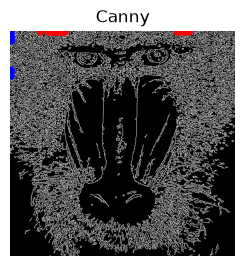

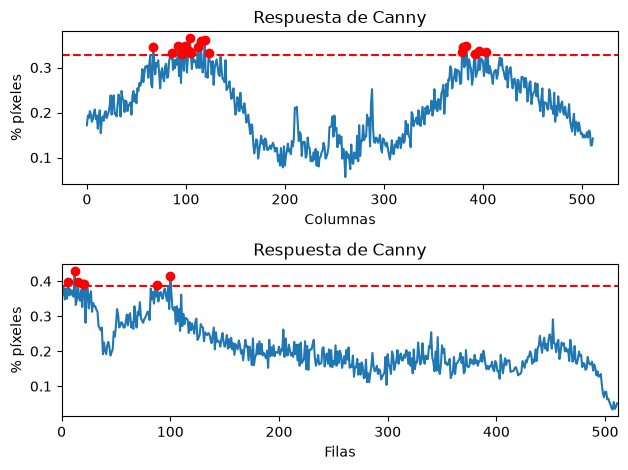

In [2]:
img = cv2.imread('mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por columna
cols = col_counts[0, :] / (255 * canny.shape[0])
rows = row_counts[:, 0] / (255 * canny.shape[1])

def calculate_threshold(data, threshold):
    max_val = np.max(data)
    threshold_value = max_val * threshold
    max_loc = np.where(data >= threshold_value)[0]
    return threshold_value, max_loc, max_val

thres_cols, cols_loc, _ = calculate_threshold(cols, 0.9)
thres_rows, rows_loc, _ = calculate_threshold(rows, 0.9)

plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray')
plt.plot(np.zeros_like(rows_loc), rows_loc, 'bo', markersize=5)
plt.plot(cols_loc, np.zeros_like(cols_loc), 'ro', markersize=5)

plt.figure()
plt.subplot(2, 1, 1)
plt.title("Respuesta de Canny")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.axhline(y=thres_cols, color='r', linestyle='--')
plt.plot(cols)
plt.plot(cols_loc, cols[cols_loc], 'ro')

plt.subplot(2, 1, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.axhline(y=thres_rows, color='r', linestyle='--')
plt.plot(rows)
plt.plot(rows_loc, rows[rows_loc], 'ro')

plt.xlim([0, canny.shape[1]])
plt.tight_layout()

---

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

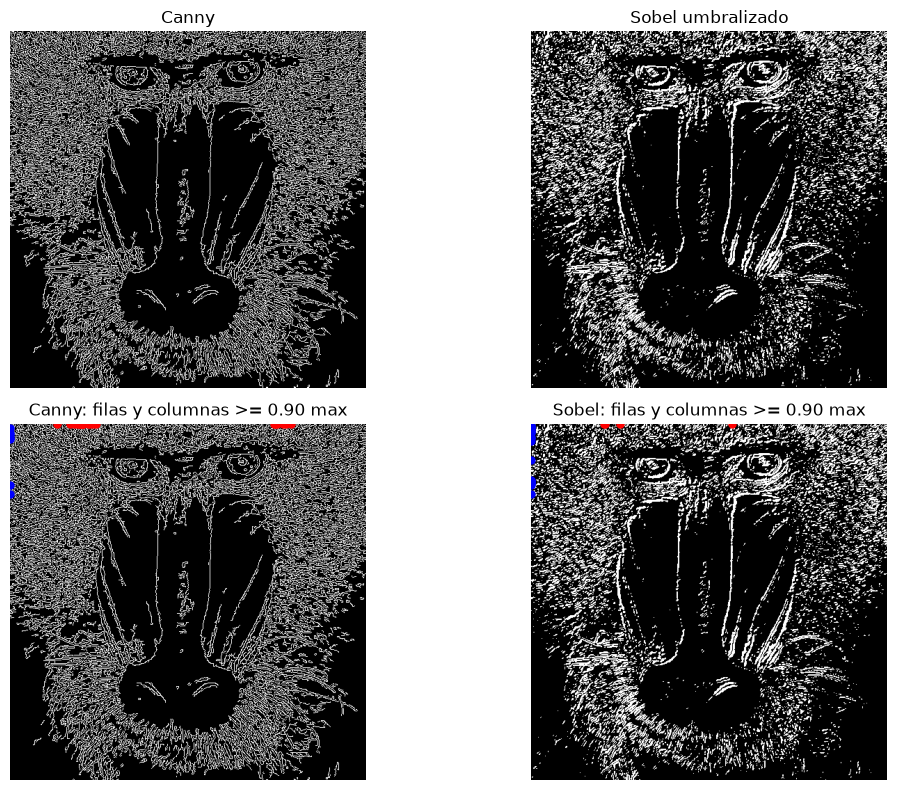

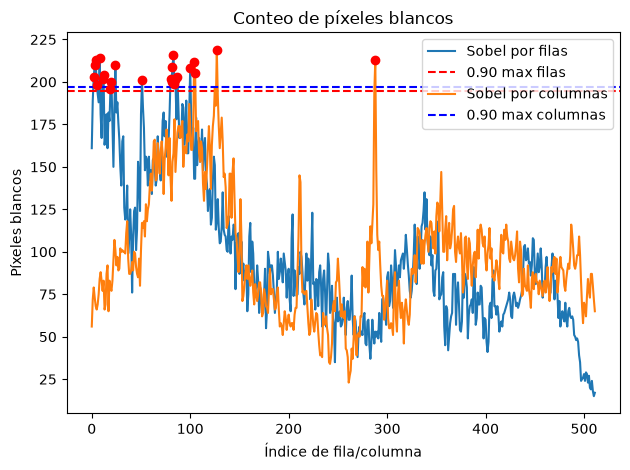

In [3]:
# Implementación de Félix

# Suavizado para reducir el ruido antes de calcular Sobel
gris_suave = cv2.GaussianBlur(gris, (3, 3), 0)
THRESHOLD = 0.90

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(gris_suave, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(gris_suave, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)
# Conversión a byte con openCV
sobel8 = cv2.convertScaleAbs(sobel)

sobelx = cv2.Sobel(gris_suave, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gris_suave, cv2.CV_64F, 0, 1, ksize=3)

sobel_magnitud = cv2.add(sobelx.astype(np.float32), sobely.astype(np.float32))
sobel8 = cv2.convertScaleAbs(sobel_magnitud)

# Umbralizado de la imagen Sobel de 8 bits
min_threshold = 100
_, sobel_umbral_mat = cv2.threshold(sobel8, min_threshold, 255, cv2.THRESH_BINARY)

# Conteo de píxeles blancos por columna y por fila
columnas_blancas = np.count_nonzero(sobel_umbral_mat, axis=0)
filas_blancas = np.count_nonzero(sobel_umbral_mat, axis=1)

thres_cols_sobel, cols_loc_sobel, max_col_sobel = calculate_threshold(columnas_blancas, THRESHOLD)
thres_rows_sobel, rows_loc_sobel, max_row_sobel = calculate_threshold(filas_blancas, THRESHOLD)


# Comparación visual: Canny frente a Sobel umbralizado
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(canny, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(sobel_umbral_mat, cmap='gray')
plt.title('Sobel umbralizado')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(canny, cmap='gray')
plt.title('Canny: filas y columnas >= 0.90 max')
plt.plot(np.zeros_like(rows_loc), rows_loc, 'bo', markersize=5)
plt.plot(cols_loc, np.zeros_like(cols_loc), 'ro', markersize=5)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(sobel_umbral_mat, cmap='gray')
plt.title('Sobel: filas y columnas >= 0.90 max')
plt.plot(np.zeros_like(rows_loc_sobel), rows_loc_sobel, 'bo', markersize=5)
plt.plot(cols_loc_sobel, np.zeros_like(cols_loc_sobel), 'ro', markersize=5)
plt.axis('off')
plt.tight_layout()

plt.figure()
plt.plot(filas_blancas, label='Sobel por filas')
plt.axhline(max_row_sobel * THRESHOLD, color='r', linestyle='--', label='0.90 max filas')
plt.plot(columnas_blancas, label='Sobel por columnas')
plt.axhline(max_col_sobel * THRESHOLD, color='b', linestyle='--', label='0.90 max columnas')
plt.xlabel('Índice de fila/columna')
plt.ylabel('Píxeles blancos')
plt.title('Conteo de píxeles blancos')
plt.plot(cols_loc_sobel, columnas_blancas[cols_loc_sobel], 'ro')
plt.plot(rows_loc_sobel, filas_blancas[rows_loc_sobel], 'ro')
plt.tight_layout()
plt.legend()

plt.tight_layout()
plt.show()

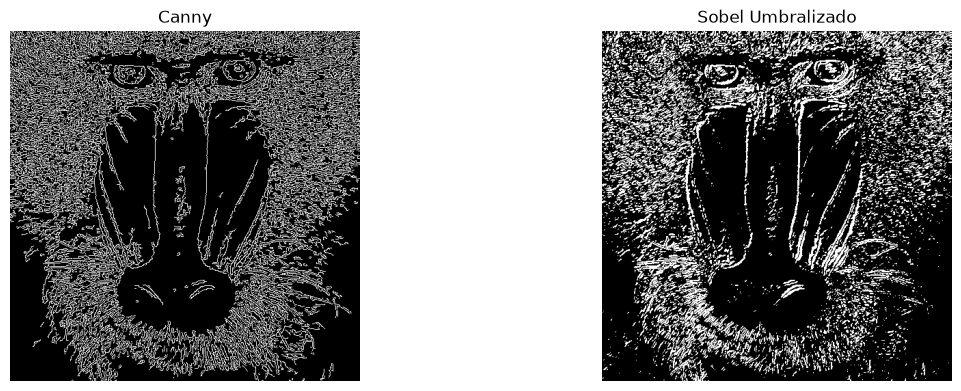

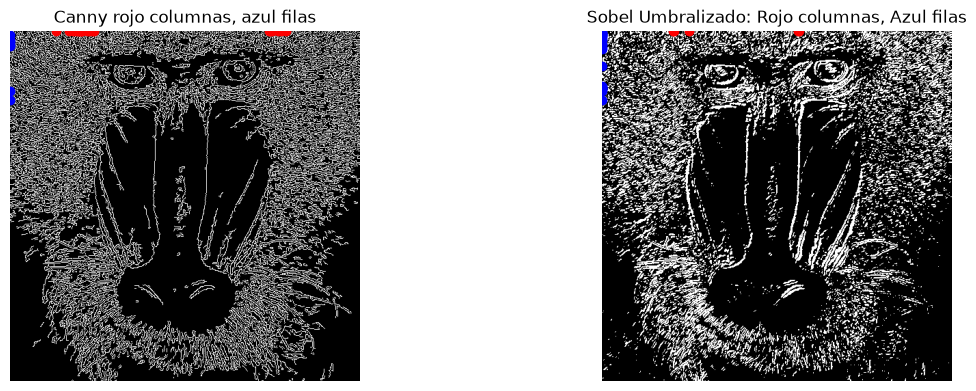

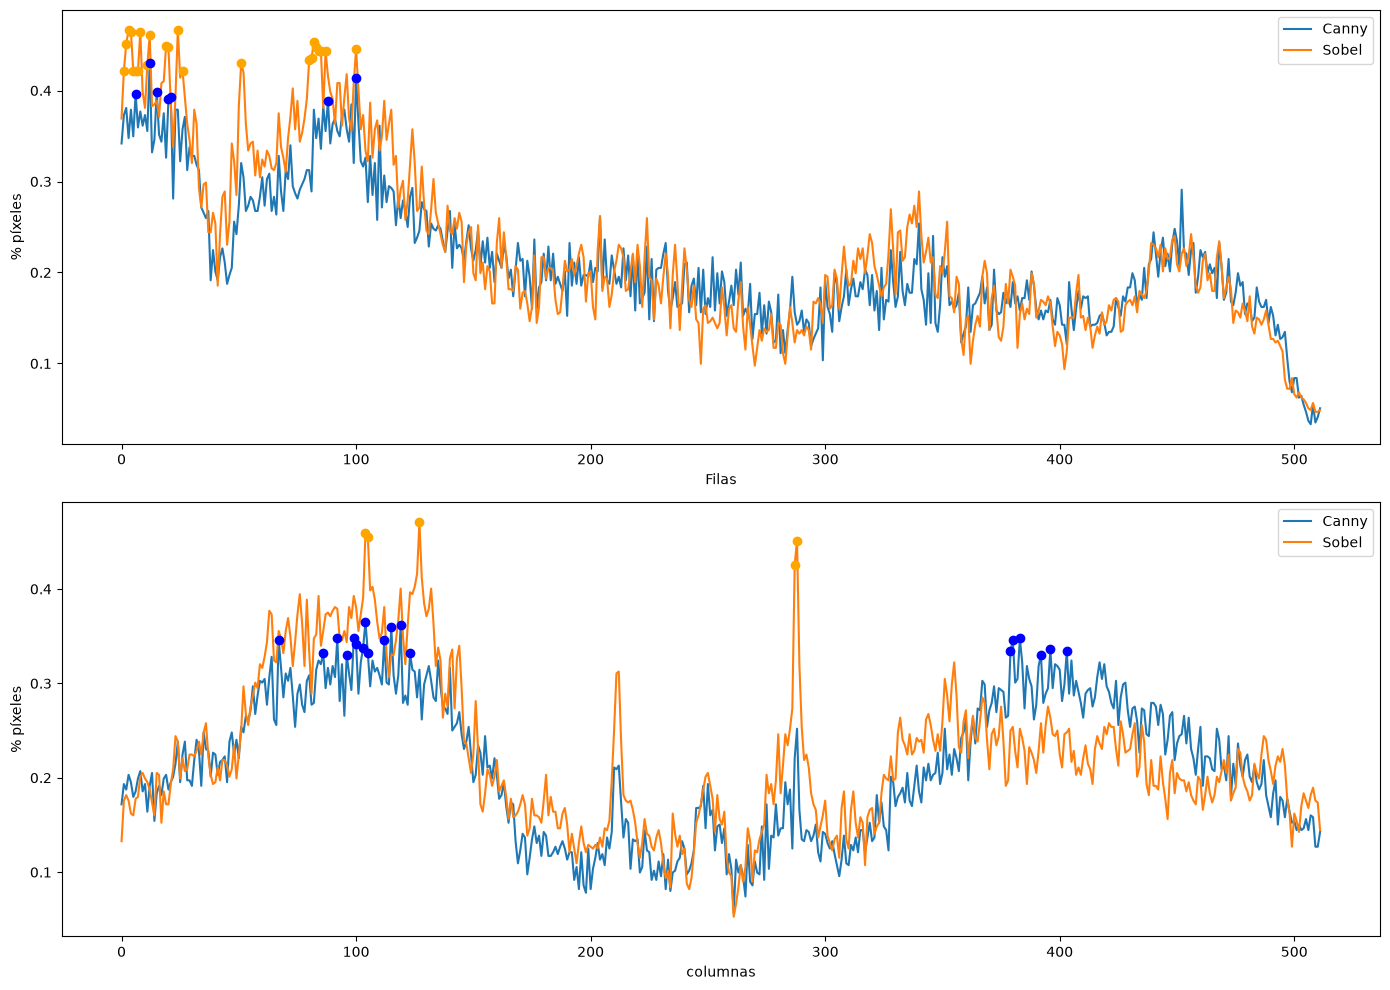

In [4]:
# Implementación de Cristina

def calculate_maxUmbral(val):
    max_val = np.max(val)
    umbral = max_val * 0.9
    position = np.where(val > umbral)[0]
    return max_val, umbral, position

# Canny
img = cv2.imread('mandril.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)

row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#Para poder nromalizarla tenemos que coger todo los valores de la primera dimensión y el primero de la segunda, [fila, fila]
rows_canny = row_counts[:,0] / (255 * canny.shape[1])
max_val_row_canny, umbral_row_canny, position_row_canny = calculate_maxUmbral(rows_canny)

cols_canny = col_counts[0] / (255 * canny.shape[0])
max_val_col_canny, umbral_col_canny, position_col_canny = calculate_maxUmbral(cols_canny)

# Imagen de sobel
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)
# Conversión a byte con openCV
sobel8 = cv2.convertScaleAbs(sobel)


valorUmbral = 90 
_, imagenUmbralizada = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)

row_count_sobel = cv2.reduce(imagenUmbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_count_sobel = cv2.reduce(imagenUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

rows_sobel = row_count_sobel[:,0] / (255 * imagenUmbralizada.shape[1])
max_val_sobel, umbral_sobel, position_row_sobel = calculate_maxUmbral(rows_sobel)
cols_sobel = col_count_sobel[0] / (255 * imagenUmbralizada.shape[0])
max_val_sobel, umbral_sobel, position_col_sobel = calculate_maxUmbral(cols_sobel)


plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 


plt.subplot(2, 2, 2)
plt.axis("off")
plt.title("Sobel Umbralizado")
plt.imshow(imagenUmbralizada, cmap='gray')

plt.show()

img_sobel_marcada = imagenUmbralizada.copy()
img_canny_marcada = canny.copy()

plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
plt.axis("off")
plt.title("Canny rojo columnas, azul filas")
plt.imshow(img_canny_marcada, cmap='gray') 
plt.plot(np.zeros_like(position_row_canny), position_row_canny, 'bo')  
plt.plot(position_col_canny,np.zeros_like(position_col_canny), 'ro')  


plt.subplot(2, 2, 2)
plt.axis("off")
plt.title("Sobel Umbralizado: Rojo columnas, Azul filas")
plt.imshow(img_sobel_marcada, cmap='gray')
plt.plot(np.zeros_like(position_row_sobel), position_row_sobel, 'bo')
plt.plot(position_col_sobel, np.zeros_like(position_col_sobel), 'ro')
plt.show()

plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)
plt.plot(rows_canny, label="Canny")
plt.plot(rows_sobel, label="Sobel")
plt.plot(position_row_sobel, rows_sobel[position_row_sobel], 'o', color='orange')
plt.plot(position_row_canny, rows_canny[position_row_canny], 'bo')
plt.xlabel("Filas"); plt.ylabel("% píxeles"); plt.legend()
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.plot(cols_canny, label="Canny")
plt.plot(cols_sobel, label="Sobel")
plt.plot(position_col_sobel, cols_sobel[position_col_sobel], 'o', color='orange')
plt.plot(position_col_canny, cols_canny[position_col_canny], 'bo')
plt.xlabel("columnas"); plt.ylabel("% píxeles"); plt.legend()
plt.tight_layout()
plt.show()




Al visualizar los resultados obtenidos mediante el umbralizado de sobel frente a la salida del Canny, podemos observar claramente el efecto de procesar la imagen por etapas.

Comparando Sobel respecto a Canny, se puede apreciar como Sobel umbralizado a 8 bits recoge mas detalles o imperfecciones en la superficie o contorno de la imagen. Atendiendo a la nariz, se puede observar como Canny resalta unos puntos gruesos redondos, mientras que Sobel lo resalta como puntos pequeños individuales esparcidos, como si fuesen motas de polvo. 

Adicionalmente, los pelos blancos individuales que salen de la nariz se ven mejor resaltados en Sobel, donde se pueden identificar mejor individualmente, mientras que en Canny esta superficie se mezcla con el ruido interior de la boca y pelaje adicional, insertando mucho ruido en la deteccion del borde.

Canny se construye precisamente sobre el gradiente de Sobel, mientras que en nuestro procedimiento manual con sobel debemos aplicar un umbralizado global. Canny añade etapas haciendo uso del filtro gausiano para reduicr el ruido, afinando los bordes con 1 pixel de grosor y un umbralizado.

El resultado es que Sobel umbralizado, los bordes tienden a ser más gruesos y mayor cantidad de ruido. Provocando que al realizar el conteo de filas y columnas pueden verse altos debido al grosor de las líneas y el rudio.

Por lo contario, Canny, observamos bordes continuos, más finos y deifnidos. En conclusión, el ejercicio ilustra cómo las etapas adicionales de Canny refinan la información.

---

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

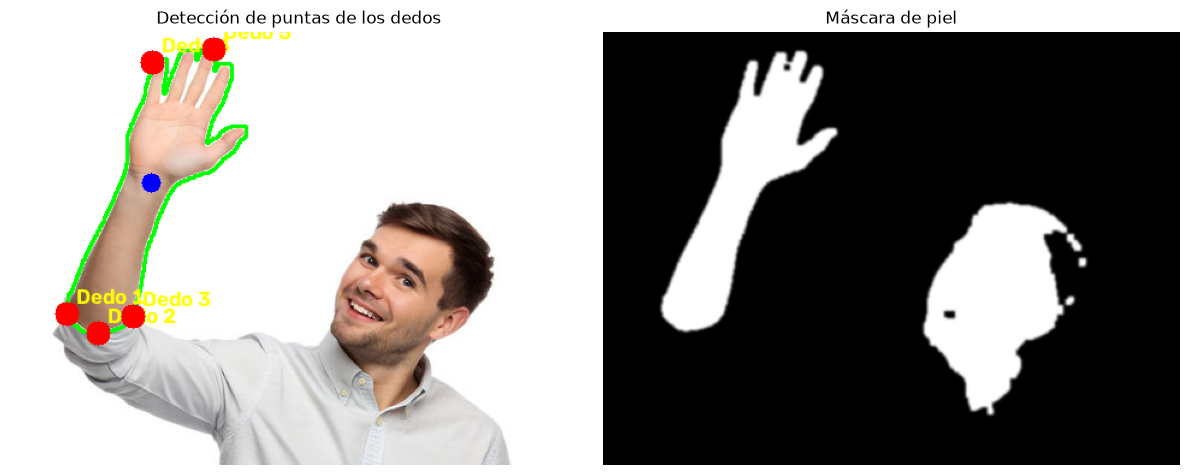

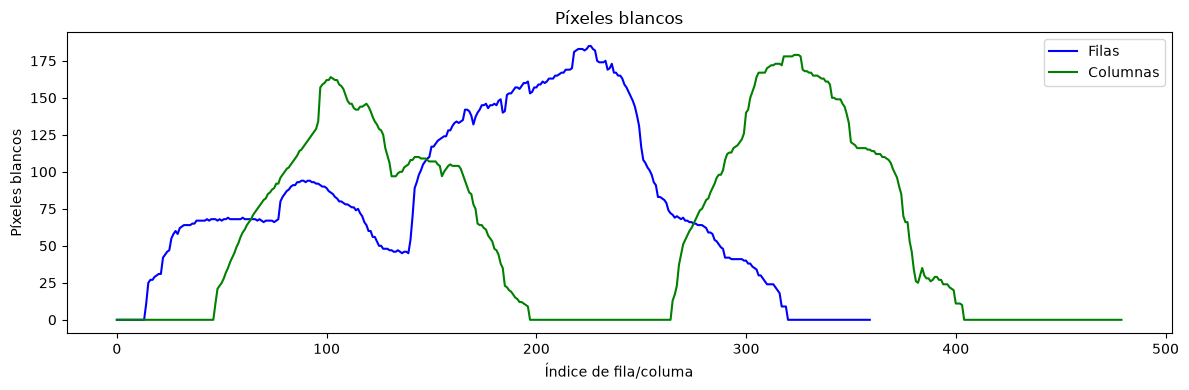

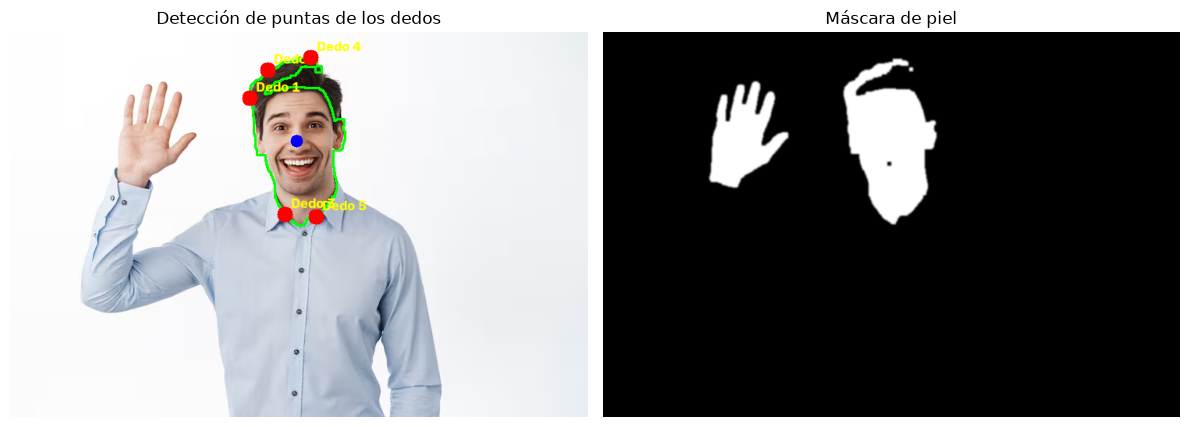

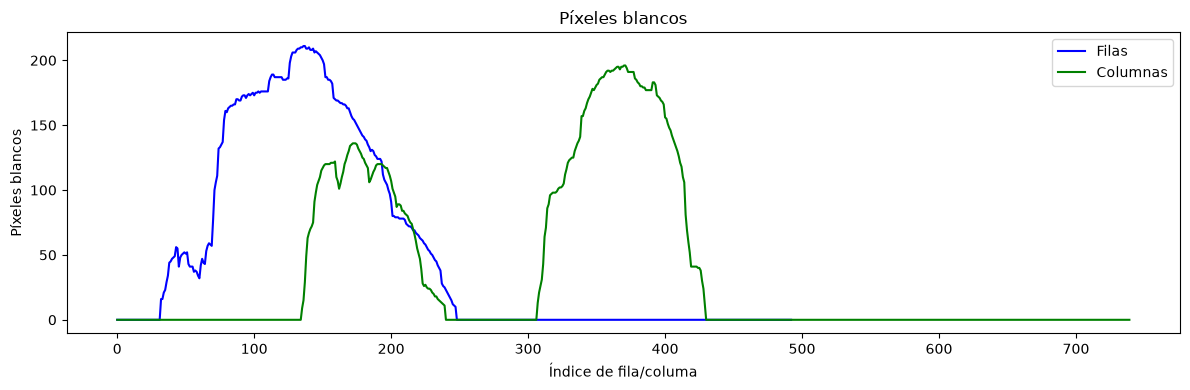

In [5]:
# Primera implementación de detección de puntas de los dedos

def detect_fingertips(frame):
    output = frame.copy()
    h, w = frame.shape[:2]

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask_hsv = cv2.inRange(
        hsv,
        np.array([0, 25, 40], dtype=np.uint8),
        np.array([25, 255, 255], dtype=np.uint8)
    )

    ycrcb = cv2.cvtColor(frame, cv2.COLOR_BGR2YCrCb)
    mask_ycrcb = cv2.inRange(
        ycrcb,
        np.array([0, 133, 77], dtype=np.uint8),
        np.array([255, 173, 127], dtype=np.uint8)
    )

    mask = cv2.bitwise_and(mask_hsv, mask_ycrcb)

    # Mascara de piel invertida para filtrar todo excepto las regiones de piel
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.GaussianBlur(mask, (5, 5), 0)

    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return output, mask, []

    # Descartar figuras parecidas a la cara: una mano abierta tiene valles entre los dedos,
    # que aparecen como defectos de convexidad en su contorno
    min_area = 0.005 * h * w
    hand_candidates = []

    for candidate in contours:
        area = cv2.contourArea(candidate)
        if area < min_area:
            continue

        hull = cv2.convexHull(candidate)
        hull_area = cv2.contourArea(hull)
        if hull_area == 0:
            continue

        solidity = area / hull_area
        defects = cv2.convexityDefects(candidate, cv2.convexHull(candidate, returnPoints=False))
        defect_count = 0 if defects is None else len(defects)
        defect_ratio = (hull_area - area) / hull_area

        # Las caras suelen ser muy sólidas y tienen pocos o ningún defecto profundo
        if defect_count >= 2 and defect_ratio >= 0.02 and solidity < 0.98:
            score = area * (1 + 5 * defect_ratio) * (1 + min(defect_count, 5) / 5)
            hand_candidates.append((score, candidate))

    if not hand_candidates:
        return output, mask, []

    _, contour = max(hand_candidates, key=lambda item: item[0])
    cv2.drawContours(output, [contour], -1, (0, 255, 0), 2)

    # Palm center
    moments = cv2.moments(contour)
    if moments["m00"] == 0:
        return output, mask, []

    center = np.array([
        moments["m10"] / moments["m00"],
        moments["m01"] / moments["m00"]
    ])

    hull = cv2.convexHull(contour)
    hull_points = hull[:, 0, :]

    distances = np.linalg.norm(hull_points - center, axis=1)
    max_distance = np.max(distances)

    # Los dedos suelen presentarse distantes del centro de la palma
    candidates = hull_points[distances > 0.72 * max_distance]

    # Quitamos puntos cercanos que podrian pertenecer a la misma punta de dedo
    min_separation = 0.08 * min(h, w)
    fingertips = []

    for point in candidates:
        if all(np.linalg.norm(point - old) > min_separation
               for old in fingertips):
            fingertips.append(point)

    fingertips = sorted(
        fingertips,
        key=lambda p: np.linalg.norm(p - center),
        reverse=True
    )[:5]

    fingertips = sorted(fingertips, key=lambda p: p[0])
    cv2.circle(
        output,
        tuple(center.astype(int)),
        8,
        (255, 0, 0),
        -1
    )

    for number, point in enumerate(fingertips, start=1):
        x, y = map(int, point)

        cv2.circle(output, (x, y), 10, (0, 0, 255), -1)
        cv2.putText(
            output,
            f"Dedo {number}",
            (x + 8, y - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 255),
            2
        )

    return output, mask, fingertips

def run_live_detection():
    vid = cv2.VideoCapture(0)
    while True:
        ret, frame = vid.read()
        if not ret:
            break

        resultado, mascara_mano, puntas = detect_fingertips(frame)

        cv2.imshow("Deteccion de puntas de los dedos", resultado)
        cv2.imshow("Mascara de piel", mascara_mano)

        if cv2.waitKey(1) == 27:
            break

    vid.release()
    cv2.destroyAllWindows()

def test_with_image(img):
    resultado, mascara_mano, puntas = detect_fingertips(img)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    plt.title("Detección de puntas de los dedos")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mascara_mano, cmap="gray")
    plt.title("Máscara de piel")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    rows_mask = np.sum(mascara_mano > 0, axis=1)
    cols_mask = np.sum(mascara_mano > 0, axis=0)

    plt.figure(figsize=(12, 4))
    plt.xlabel("Índice de fila/columa")
    plt.ylabel("Píxeles blancos")
    plt.title("Píxeles blancos")
    plt.plot(rows_mask, color="blue", label="Filas")
    plt.plot(cols_mask, color="green", label="Columnas")
    plt.legend()

    plt.tight_layout()
    plt.show()

waving_hand_img = cv2.imread('waving_hand.jpg')
test_with_image(waving_hand_img)
waving_hand_img_2 = cv2.imread('waving_hand_2.avif')
test_with_image(waving_hand_img_2)
# run_live_detection()

En esta primera iteración, se atiende a, mediante funciones de ayuda de OpenCV, identificar patrones morfología de las manos y dedos. Usando tecnicas como convolucion simple mediante kernels para la estracción mecanica de características usando una mascara blanco y negro filtrada previamente para destacar aquellos colores que se asemejen más a la piel.

Usando `cv2.moments`, podemos probar a identificar el centro de una figura identificada, con el objetivo de buscar el centro de la palma de la mano, y a partir de este, buscar los mejores candidatos a ser dedos. Como se aprecia en los ejemplos, Esta identificacion resulta compleja, dado que el algoritmo suele confundir objetos solidos y redondos como la cabeza con la mano real.

Teniendo en cuenta esto, podemos evaluar el histograma de pixeles blancos por filas y columnas. Dado que la mano suele estar presente de forma vertical, se aprecian en las columnas una montaña con varios picos, frente a otra montaña con un solo pico. Este punto clave sería lo que nos llevaria a mejorar el algoritmo. Teniendo la capacidad de extraer y distinguir las montañas con picos que asemejen los espacios entre los dedos de una mano, podemos refinar el algoritmo para tener una mejor idea de que y que no puede ser una mano.

- [cv2.moments](https://learnopencv.com/find-center-of-blob-centroid-using-opencv-cpp-python/)
- [cv2.convexHull para mejorar la detección de manos](https://docs.opencv.org/3.4.20/d7/d1d/tutorial_hull.html)
- [cv2.morphologyEx para la mascara de piel](https://learnopencv.com/invisibility-cloak-using-color-detection-and-segmentation-with-opencv/)

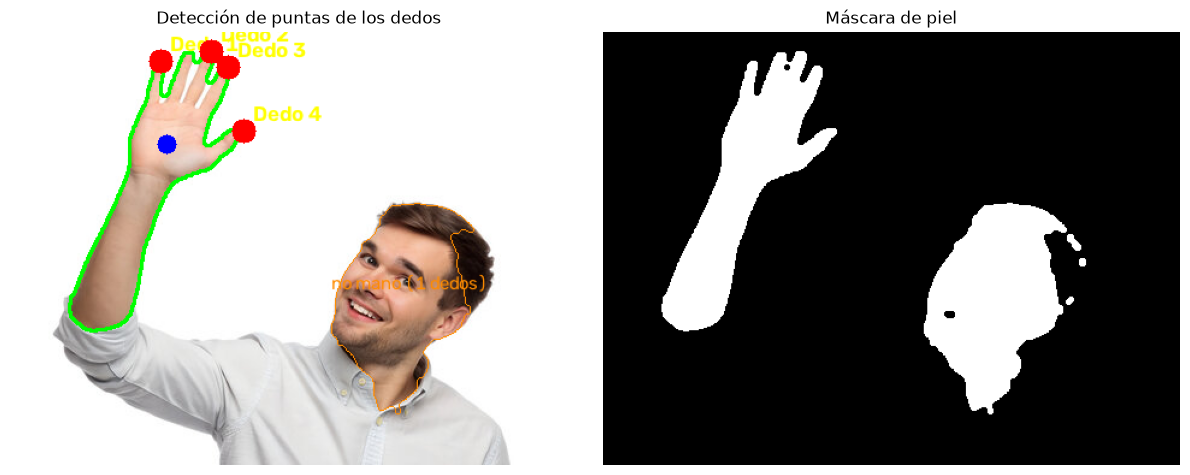

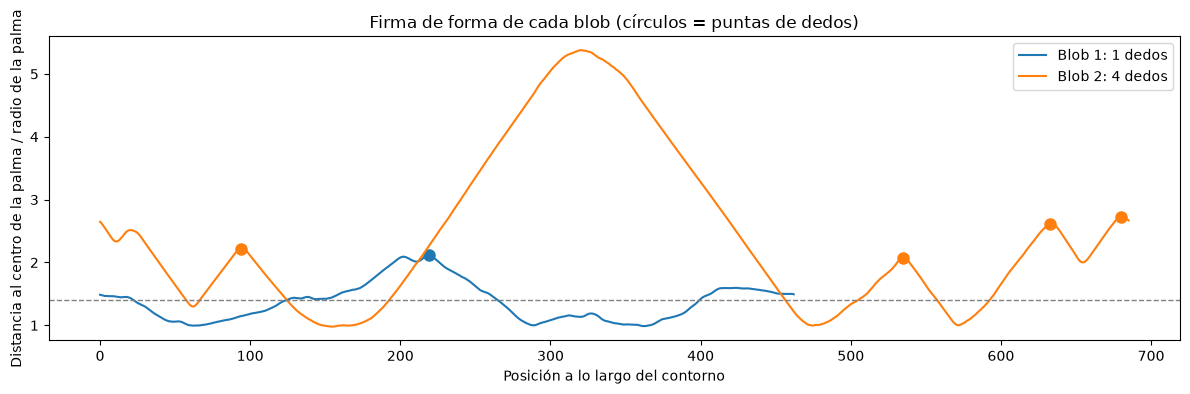

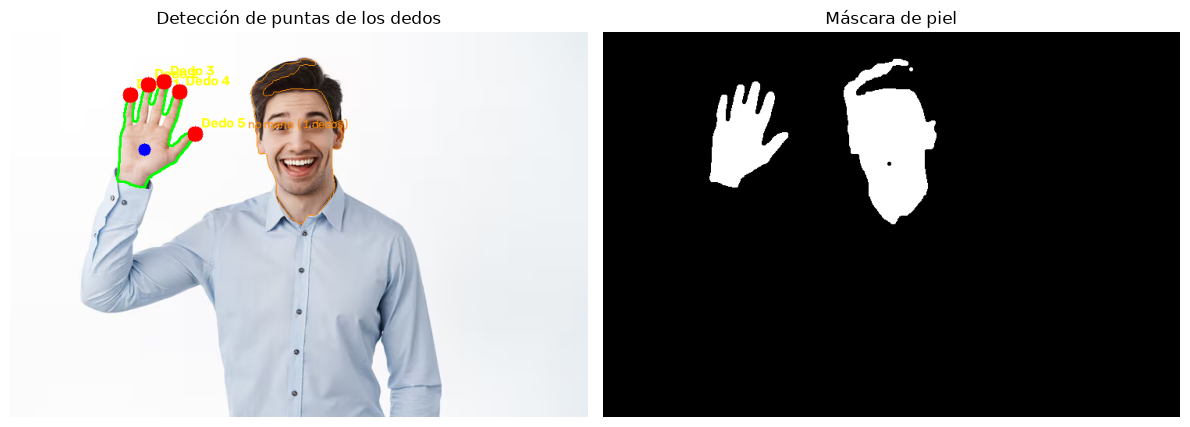

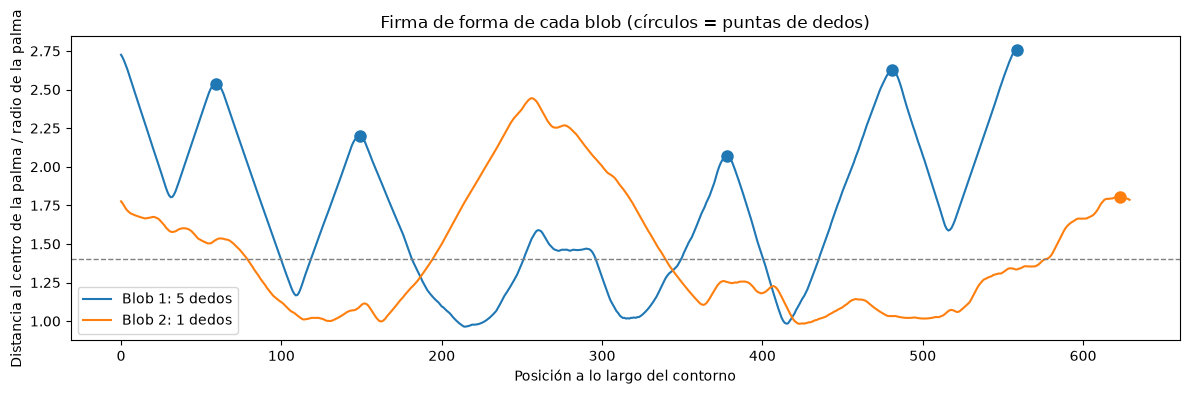

In [6]:
from scipy.signal import find_peaks
import random

# Parametros
MIN_AREA_FRAC = 0.005   # ignorar figuras mas pequeñas que este porcentaje del area de la imagen
MIN_FINGERS = 2         # minimo de dedos para considerar que es una mano
MIN_TIP_DIST = 1.4      # distancia minima de una punta de dedo al centro de la palma (x r)
MIN_PROMINENCE = 0.20   # en los picos del histograma, cuanto tiene que sobresalir (x r)
MIN_PROTRUSION = 0.45   # cuanto tiene que sobresalir una punta de dedo de la palma(x r)
CORE_OPENING = 0.55     # radio del nucleo (x r)
MAX_TIP_SPREAD = 170    # angulo maximo para considerar un dedo como parte de la misma mano (grados) 

class Burbuja:
    """
    Clase Burbuja para dibujar las burbujas en la pantalla. 
    Contiene atributos como posición, velocidad, radio, color y vida de la burbuja.
    """
    
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.vx = random.uniform(-2, 2)
        self.vy = random.uniform(-6, -2) 
        self.radio = random.randint(5, 25) 
        
        self.color = (random.randint(150, 255), random.randint(200, 255), random.randint(200, 255))
        self.vida = random.randint(100, 200)

    def actualizar(self):
        self.x += self.vx
        self.y += self.vy
        self.vida -= 4 
        self.vx += random.uniform(-0.5, 0.5) 


def skin_mask(frame):
    """
    Segmentacion del color piel y creacion de su mascara.
    """
    
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask_hsv = cv2.inRange(
        hsv,
        np.array([0, 25, 40], dtype=np.uint8),
        np.array([25, 255, 255], dtype=np.uint8)
    )

    ycrcb = cv2.cvtColor(frame, cv2.COLOR_BGR2YCrCb)
    mask_ycrcb = cv2.inRange(
        ycrcb,
        np.array([0, 133, 77], dtype=np.uint8),
        np.array([255, 173, 127], dtype=np.uint8)
    )

    mask = cv2.bitwise_and(mask_hsv, mask_ycrcb)
    
    # Mascara de piel invertida para filtrar todo excepto las regiones de piel
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.GaussianBlur(mask, (5, 5), 0)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    
    return mask

def circular_smooth(signal, k):
    """
    Identificacion de picos suavizando la señal circular mediante convolución con un kernel
    """
    
    if k <= 0:
        return signal

    padded = np.concatenate([signal[-k:], signal, signal[:k]])
    kernel = np.ones(2 * k + 1) / (2 * k + 1)
    return np.convolve(padded, kernel, mode="valid")

def circular_peaks(signal, prominence, height):
    """
    Identificación de picos, considerando posibles picos en las señales circulares, es decir, 
    que se repiten al final de la señal
    """
    
    n = len(signal)
    tiled = np.tile(signal, 3)
    idx, _ = find_peaks(tiled, prominence=prominence, height=height)
    return np.array(sorted({int(i - n) for i in idx if n <= i < 2 * n}), dtype=int)

def analyze_blob(contour, shape):
    """
    Analiza un contorno de piel y devuelve información sobre su forma y posibles puntas de dedos
    
    Mediante analisis previo de histogramas, evaluamos la extracción de picos que parezcan
    dedos, figuras solidas cercanas que aparenten ser la palma de la mano, y el descarte de otros picos
    que no sigan el criterio, como cabezas o codos.
    """
    h, w = shape
    filled = np.zeros((h, w), np.uint8)
    cv2.drawContours(filled, [contour], -1, 255, thickness=-1)

    # Centro de la palma y su radio aproximado
    dist = cv2.distanceTransform(filled, cv2.DIST_L2, 5)
    _, r, _, c_loc = cv2.minMaxLoc(dist)
    center = np.array(c_loc, dtype=np.float64)
    r = max(float(r), 1.0)

    # Identificar el centro o nucleo, que es la parte gruesa de la mano, para descartar picos que no sean dedos
    core_thres = max(1, CORE_OPENING * r)
    eroded = (dist >= core_thres).astype(np.uint8)
    core = cv2.distanceTransform(1 - eroded, cv2.DIST_L2, 5) <= core_thres
    dist_to_core = cv2.distanceTransform((~core).astype(np.uint8), cv2.DIST_L2, 5)

    # Normalizado y suavizado de los puntos de contorno y picos
    pts = contour[:, 0, :].astype(np.float64)
    signature = np.linalg.norm(pts - center, axis=1) / r
    signature = circular_smooth(signature, max(2, int(0.06 * r)))
    peaks = circular_peaks(signature, MIN_PROMINENCE, MIN_TIP_DIST)

    # Descartar picos que no sobresalgan lo suficiente de la palma (como un codo)
    # e identificar los picos que son puntas de dedos
    fingers = []
    for p in peaks:
        x, y = pts[p]
        xi = int(np.clip(round(x), 0, w - 1))
        yi = int(np.clip(round(y), 0, h - 1))
        if dist_to_core[yi, xi] >= MIN_PROTRUSION * r:
            fingers.append(p)

    # Evaluacion de posibles picos cambados de lado
    if len(fingers) > 1:
        ang = np.degrees(np.arctan2(pts[fingers, 1] - center[1],
                                    pts[fingers, 0] - center[0])) % 360
        best = []
        for i in range(len(fingers)):
            group = [j for j in range(len(fingers))
                     if (ang[j] - ang[i]) % 360 <= MAX_TIP_SPREAD]
            if len(group) > len(best):
                best = group
        fingers = [fingers[j] for j in best]

    # Filtramos los mejores 5 candidatos a dedo
    if len(fingers) > 5:
        fingers = sorted(fingers, key=lambda i: signature[i], reverse=True)[:5]

    return {
        "contour": contour,
        "center": center,
        "radius": r,
        "signature": signature,
        "peaks": peaks,
        "finger_idx": np.array(sorted(fingers), dtype=int),
        "tips": [pts[i] for i in sorted(fingers)],
        "area": cv2.contourArea(contour),
    }


def find_blobs(mask):
    """
    Crear los contornos de la piel para analizar cada figura
    """

    h, w = mask.shape[:2]
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )
    min_area = MIN_AREA_FRAC * h * w
    return [
        analyze_blob(c, (h, w))
        for c in contours
        if cv2.contourArea(c) >= min_area and len(c) >= 20
    ]

def detect_fingertips(frame, debug=False):
    output = frame.copy()
    mask = skin_mask(frame)

    blobs = find_blobs(mask)
    hands = [b for b in blobs if len(b["tips"]) >= MIN_FINGERS]

    if debug:
        # Dibujar contornos de figuras que no son manos y etiquetarlos
        for b in blobs:
            if len(b["tips"]) < MIN_FINGERS:
                cv2.drawContours(output, [b["contour"]], -1, (0, 140, 255), 1)
                cx, cy = b["center"].astype(int)
                cv2.putText(output, f"no mano ({len(b['tips'])} dedos)",
                            (cx - 60, cy), cv2.FONT_HERSHEY_SIMPLEX,
                            0.5, (0, 140, 255), 1)

    if not hands:
        return output, mask, []

    # Seleccionar la mano con más dedos detectados, y en caso de empate, la más grande
    hand = max(hands, key=lambda b: (len(b["tips"]), b["area"]))

    cv2.drawContours(output, [hand["contour"]], -1, (0, 255, 0), 2)
    cv2.circle(output, tuple(hand["center"].astype(int)), 8, (255, 0, 0), -1)

    fingertips = sorted(hand["tips"], key=lambda p: p[0])

    for number, point in enumerate(fingertips, start=1):
        x, y = map(int, point)
        cv2.circle(output, (x, y), 10, (0, 0, 255), -1)
        cv2.putText(
            output,
            f"Dedo {number}",
            (x + 8, y - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 255),
            2
        )

    return output, mask, fingertips

def test_with_image(img):
    resultado, mascara_mano, puntas = detect_fingertips(img, debug=True)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    plt.title("Detección de puntas de los dedos")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mascara_mano, cmap="gray")
    plt.title("Máscara de piel")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    blobs = find_blobs(mascara_mano)
    plt.figure(figsize=(12, 4))
    for n, b in enumerate(blobs, start=1):
        sig = b["signature"]
        line, = plt.plot(sig, label=f"Blob {n}: {len(b['tips'])} dedos")
        plt.plot(b["finger_idx"], sig[b["finger_idx"]], "o",
                 color=line.get_color(), markersize=8)
    plt.axhline(MIN_TIP_DIST, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("Posición a lo largo del contorno")
    plt.ylabel("Distancia al centro de la palma / radio de la palma")
    plt.title("Firma de forma de cada blob (círculos = puntas de dedos)")
    plt.legend()

    plt.tight_layout()
    plt.show()

def run_live_detection():
    vid = cv2.VideoCapture(0)
    while True:
        ret, frame = vid.read()
        if not ret:
            break

        resultado, mascara_mano, puntas = detect_fingertips(frame)

        cv2.imshow("Deteccion de puntas de los dedos", resultado)
        cv2.imshow("Mascara de piel", mascara_mano)

        if cv2.waitKey(1) == 27:
            break

    vid.release()
    cv2.destroyAllWindows()

def run_live_detection_with_bubbles():
    vid = cv2.VideoCapture(1)
    lista_burbujas = []

    while True:
        ret, frame = vid.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)
        resultado, mascara_mano, puntas = detect_fingertips(frame)

        for point in puntas:
            x, y = map(int, point)
            
            if random.random() < 0.65: 
                lista_burbujas.append(Burbuja(x, y))

        for burbuja in lista_burbujas[:]: 
            burbuja.actualizar() 
            
            if burbuja.vida <= 0 or burbuja.y < 0 or burbuja.x < 0 or burbuja.x > frame.shape[1]:
                lista_burbujas.remove(burbuja)
            else:
                cv2.circle(resultado, (int(burbuja.x), int(burbuja.y)), int(burbuja.radio), burbuja.color, 2)

        cv2.imshow("Hand Tracking & Bubbles", resultado)
        cv2.imshow("Skin Mask", mascara_mano)

        if cv2.waitKey(1) == 27:
            break

    vid.release()
    cv2.destroyAllWindows()

waving_hand_img = cv2.imread('waving_hand.jpg')
test_with_image(waving_hand_img)
waving_hand_img_2 = cv2.imread('waving_hand_2.avif')
test_with_image(waving_hand_img_2)
run_live_detection_with_bubbles()

Mediante mayor refinamiento del algoritmo, y con la inclusion de librerias como SciPy que permitan usar funciones como `find_peaks` para identificar con mayor precion los picos que estamos buscando, hemos podido aislar los valles que estabamos buscando, los cuales serian el mejor intento a identificar los dedos de una mano, para luego, junto a `cv2.moments`, mejorar la deteccion del centro de la palma de la mano.

Junto a esto, se fijan marcadores en las puntas de los dedos para, de forma interactiva, expulsar burbujas por aquello que el algoritmo detecta que es un dedo y su punta.

Cabe destacar que el algoritmo no se muy preciso, dado que depende completamente de la extracción correcta de colores, y en muchos casos la calidad de los colores depende de la camara del dispositivo o la imagen.

- [Claude: mejora de algoritmo mediante extracción de picos de manos](https://claude.ai/share/861b40c9-9988-4fab-b119-7dc6619a91d9)
- [Gemini: Implementación del filtro de burbujas](https://claude.ai/share/861b40c9-9988-4fab-b119-7dc6619a91d9)